# Breast Ultrasound Classification (BUSI)
## Ablation Study: Addressing Class Imbalance via Generative Data Augmentation

**4 Regimes Compared:**
- **A** — Baseline (No Augmentation)
- **B** — Classical Augmentation (Flip, Rotation, Affine, Color Jitter)
- **C** — Vanilla WGAN-GP Augmentation
- **D** — Mask-Aware WGAN-GP Augmentation (with Real Tissue Backgrounds)

**Key Improvements in this version:**
1. **Deeper Generator** with ConvTranspose2d progressive upsampling
2. **WGAN-GP Loss** for stable GAN training (replaces BCE)
3. **200 GAN epochs** with periodic sample visualization
4. **FID-based evaluation** of generated image quality
5. **LR Scheduler** (ReduceLROnPlateau) for all classifiers
6. **Weight Decay** (1e-4) for regularization
7. **Early Stopping** (patience=7) to prevent overfitting
8. **Layer Freezing** (5 epochs) — freeze backbone, train head first
9. **Label Smoothing** (0.1) in CrossEntropyLoss
10. **Real tissue backgrounds** for mask-aware blending (replaces random noise)
11. **Masks for both benign and malignant** classes
12. **Classical augmentation on real data** in Regimes C & D for fair comparison
13. **Complete visualizations** — training curves, GAN samples, final comparison charts

In [17]:
# CELL 1: Environment Setup and Data Pipeline
import os
import random
import numpy as np
import glob
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, ConcatDataset
from torchvision import transforms, models
from torchvision.utils import make_grid
from sklearn.model_selection import train_test_split

import time
import copy
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Reproducibility ----
SEED = 42
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ---- Dataset Path Discovery ----
print("Searching for dataset...")
possible_paths = glob.glob('/kaggle/input/**/Dataset_BUSI_with_GT/', recursive=True)
if possible_paths:
    DATA_PATH = possible_paths[0]
elif os.path.exists('./Dataset_BUSI_with_GT/'):
    DATA_PATH = './Dataset_BUSI_with_GT/'
else:
    raise FileNotFoundError("Dataset_BUSI_with_GT not found!")
print(f"Dataset at: {DATA_PATH}")

classes = ['normal', 'benign', 'malignant']

# ---- Collect Images (exclude masks) ----
filepaths = []
labels = []
for class_idx, class_name in enumerate(classes):
    class_path = os.path.join(DATA_PATH, class_name)
    for img_path in glob.glob(os.path.join(class_path, '*.png')):
        if 'mask' not in img_path:
            filepaths.append(img_path)
            labels.append(class_idx)

print(f"Total images: {len(filepaths)}")
for i, c in enumerate(classes):
    print(f"  {c}: {labels.count(i)}")

# ---- Stratified Split (60/20/20) ----
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    filepaths, labels, test_size=0.4, random_state=SEED, stratify=labels)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

# ---- Dataset Class ----
class BUSIDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.filepaths)
    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# ---- Transforms ----
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

classical_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ---- DataLoaders ----
BATCH_SIZE = 16
train_loader = DataLoader(BUSIDataset(train_paths, train_labels, base_transform),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(BUSIDataset(val_paths, val_labels, base_transform),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(BUSIDataset(test_paths, test_labels, base_transform),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("DataLoaders ready.")

Using device: cuda
GPU: Tesla T4
Searching for dataset...
Dataset at: /kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/
Total images: 780
  normal: 133
  benign: 437
  malignant: 210
Train: 468 | Val: 156 | Test: 156
DataLoaders ready.


In [18]:
# CELL 2: Core Helper Functions
final_metrics = {}
NUM_EPOCHS = 20

def train_model(model, criterion, optimizer, train_dl, val_dl,
                num_epochs=NUM_EPOCHS, freeze_epochs=5, patience=7):
    """
    Train classifier with:
    - Layer freezing: backbone frozen for first `freeze_epochs` epochs
    - LR scheduler: ReduceLROnPlateau on val loss
    - Early stopping: stops after `patience` epochs without val loss improvement
    """
    since = time.time()
    best_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

    # Phase 1: Freeze backbone layers (only train FC head)
    if freeze_epochs > 0:
        for name, param in model.named_parameters():
            if 'fc' not in name:
                param.requires_grad = False
        print(f"  [Freeze] Backbone frozen for first {freeze_epochs} epochs")

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    for epoch in range(num_epochs):
        # Unfreeze backbone after freeze_epochs
        if epoch == freeze_epochs and freeze_epochs > 0:
            for param in model.parameters():
                param.requires_grad = True
            no_improve = 0  # Reset early stopping counter
            print(f"  [Unfreeze] All layers trainable from epoch {epoch+1}")

        print(f'Epoch [{epoch+1}/{num_epochs}]', end=' ')

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dl = train_dl
            else:
                model.eval()
                dl = val_dl

            running_loss = 0.0
            all_preds, all_labels = [], []

            for inputs, lbls in dl:
                inputs, lbls = inputs.to(device), lbls.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, lbls)
                    _, preds = torch.max(outputs, 1)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(lbls.cpu().numpy())

            epoch_loss = running_loss / len(dl.dataset)
            epoch_acc = accuracy_score(all_labels, all_preds)
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                print(f'| Train Loss: {epoch_loss:.4f}', end=' ')
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                history['val_f1'].append(epoch_f1)
                scheduler.step(epoch_loss)
                print(f'| Val Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} F1: {epoch_f1:.4f}')

                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_wts = copy.deepcopy(model.state_dict())
                    no_improve = 0
                else:
                    no_improve += 1

        if no_improve >= patience:
            print(f"  [Early Stop] No improvement for {patience} epochs.")
            break

    elapsed = time.time() - since
    print(f'Training done in {elapsed//60:.0f}m {elapsed%60:.0f}s | Best Val Loss: {best_loss:.4f}')
    model.load_state_dict(best_wts)
    return model, history


def evaluate_on_test(model, dataloader, class_names, title):
    """Evaluate on test set, print report, show confusion matrix, return metrics."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, lbls in dataloader:
            inputs, lbls = inputs.to(device), lbls.to(device)
            _, preds = torch.max(model(inputs), 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    print(f"\n--- {title} ---")
    rpt = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True, zero_division=0)
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.title(title)
    plt.show()

    return {
        'Accuracy': accuracy_score(all_labels, all_preds),
        'Macro F1': f1_score(all_labels, all_preds, average='macro'),
        'Normal F1': rpt.get('normal', {}).get('f1-score', 0),
        'Benign F1': rpt.get('benign', {}).get('f1-score', 0),
        'Malignant F1': rpt.get('malignant', {}).get('f1-score', 0),
    }


def plot_training_history(history, title):
    """Plot loss, accuracy, and F1 curves for a single regime."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(history['train_loss'], label='Train', lw=2)
    axes[0].plot(history['val_loss'], label='Val', lw=2)
    axes[0].set_title(f'{title} - Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['val_acc'], label='Val Acc', color='green', lw=2)
    axes[1].set_title(f'{title} - Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(history['val_f1'], label='Val F1', color='orange', lw=2)
    axes[2].set_title(f'{title} - Macro F1'); axes[2].set_xlabel('Epoch')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_final_comparison(metrics_dict):
    """Print table and bar charts comparing all regimes."""
    df = pd.DataFrame(metrics_dict).T
    print("\n" + "="*65)
    print("FINAL COMPARATIVE RESULTS")
    print("="*65)
    print(df.to_string(float_format='%.4f'))
    print("="*65)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    df[['Accuracy', 'Macro F1']].plot(kind='bar', ax=axes[0],
        color=['#2196F3', '#FF9800'], edgecolor='black')
    axes[0].set_title('Overall Performance', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Score'); axes[0].set_ylim(0.65, 1.0)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
    axes[0].legend(loc='lower right'); axes[0].grid(axis='y', alpha=0.3)

    df[['Normal F1', 'Benign F1', 'Malignant F1']].plot(kind='bar', ax=axes[1],
        color=['#4CAF50', '#9C27B0', '#F44336'], edgecolor='black')
    axes[1].set_title('Per-Class F1 Scores', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('F1'); axes[1].set_ylim(0.4, 1.0)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
    axes[1].legend(loc='lower right'); axes[1].grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

print("Helper functions defined.")

Helper functions defined.


REGIME A: Baseline (No Augmentation)
  [Freeze] Backbone frozen for first 5 epochs
Epoch [1/20] | Train Loss: 1.0152 | Val Loss: 1.0604 Acc: 0.5449 F1: 0.2351
Epoch [2/20] | Train Loss: 0.9960 | Val Loss: 1.0132 Acc: 0.5321 F1: 0.2937
Epoch [3/20] | Train Loss: 0.9874 | Val Loss: 0.9793 Acc: 0.5449 F1: 0.3451
Epoch [4/20] | Train Loss: 0.9687 | Val Loss: 0.9590 Acc: 0.5577 F1: 0.3481
Epoch [5/20] | Train Loss: 0.9624 | Val Loss: 0.9499 Acc: 0.5705 F1: 0.3475
  [Unfreeze] All layers trainable from epoch 6
Epoch [6/20] | Train Loss: 0.7549 | Val Loss: 0.6093 Acc: 0.8333 F1: 0.8206
Epoch [7/20] | Train Loss: 0.3905 | Val Loss: 0.6510 Acc: 0.7949 F1: 0.7413
Epoch [8/20] | Train Loss: 0.3748 | Val Loss: 0.5857 Acc: 0.8397 F1: 0.8087
Epoch [9/20] | Train Loss: 0.3355 | Val Loss: 0.5813 Acc: 0.8205 F1: 0.7840
Epoch [10/20] | Train Loss: 0.3285 | Val Loss: 0.5911 Acc: 0.8397 F1: 0.7934
Epoch [11/20] | Train Loss: 0.3239 | Val Loss: 0.5631 Acc: 0.8397 F1: 0.8023
Epoch [12/20] | Train Loss: 0.32

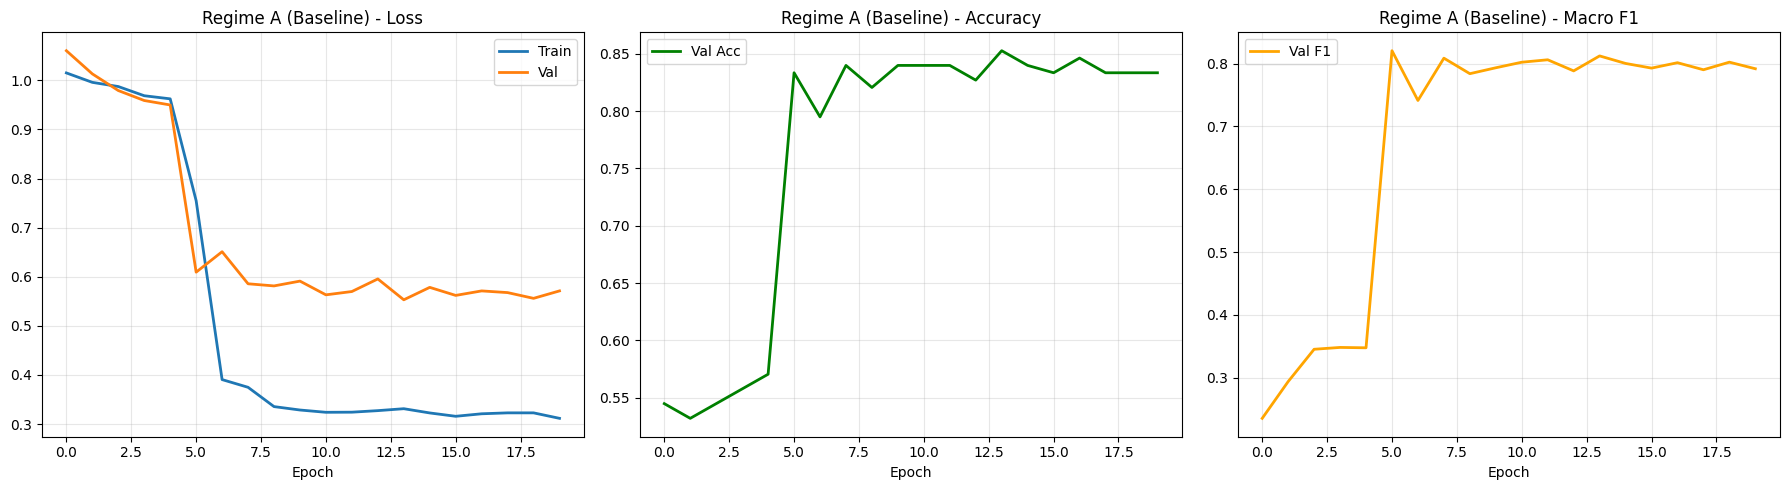


--- Regime A (Baseline) ---
              precision    recall  f1-score   support

      normal       0.74      0.63      0.68        27
      benign       0.83      0.89      0.86        87
   malignant       0.82      0.79      0.80        42

    accuracy                           0.81       156
   macro avg       0.80      0.77      0.78       156
weighted avg       0.81      0.81      0.81       156



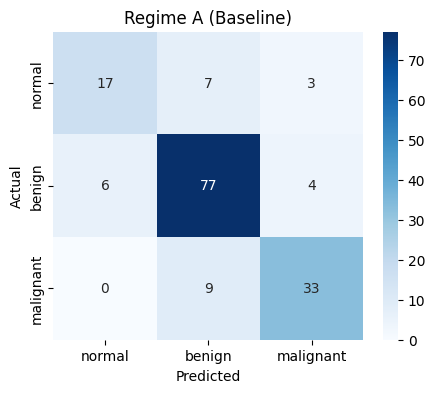

In [19]:
# CELL 3: Regime A - Baseline (No Augmentation)
# Uses: label smoothing, weight decay, LR scheduler, layer freezing, early stopping
print("="*60)
print("REGIME A: Baseline (No Augmentation)")
print("="*60)

model_a = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_a.fc = nn.Linear(model_a.fc.in_features, len(classes))
model_a = model_a.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # Label smoothing
optimizer_a = optim.Adam(model_a.parameters(), lr=1e-4, weight_decay=1e-4)

best_model_a, history_a = train_model(model_a, criterion, optimizer_a, train_loader, val_loader)
plot_training_history(history_a, "Regime A (Baseline)")
metrics_a = evaluate_on_test(best_model_a, test_loader, classes, "Regime A (Baseline)")
final_metrics['A: Baseline'] = metrics_a

REGIME B: Classical Augmentation
  [Freeze] Backbone frozen for first 5 epochs
Epoch [1/20] | Train Loss: 1.0681 | Val Loss: 0.9894 Acc: 0.5192 F1: 0.5057
Epoch [2/20] | Train Loss: 0.9983 | Val Loss: 0.9558 Acc: 0.5833 F1: 0.4169
Epoch [3/20] | Train Loss: 1.0023 | Val Loss: 0.9562 Acc: 0.5577 F1: 0.2397
Epoch [4/20] | Train Loss: 0.9925 | Val Loss: 0.9435 Acc: 0.5705 F1: 0.2812
Epoch [5/20] | Train Loss: 1.0093 | Val Loss: 0.9381 Acc: 0.5641 F1: 0.2548
  [Unfreeze] All layers trainable from epoch 6
Epoch [6/20] | Train Loss: 0.8706 | Val Loss: 0.7334 Acc: 0.7372 F1: 0.7132
Epoch [7/20] | Train Loss: 0.6830 | Val Loss: 0.6570 Acc: 0.8269 F1: 0.8057
Epoch [8/20] | Train Loss: 0.6562 | Val Loss: 0.7338 Acc: 0.7115 F1: 0.6173
Epoch [9/20] | Train Loss: 0.6281 | Val Loss: 0.8459 Acc: 0.7179 F1: 0.5818
Epoch [10/20] | Train Loss: 0.5711 | Val Loss: 0.6735 Acc: 0.8077 F1: 0.7864
Epoch [11/20] | Train Loss: 0.5460 | Val Loss: 0.6099 Acc: 0.8205 F1: 0.7855
Epoch [12/20] | Train Loss: 0.5227 |

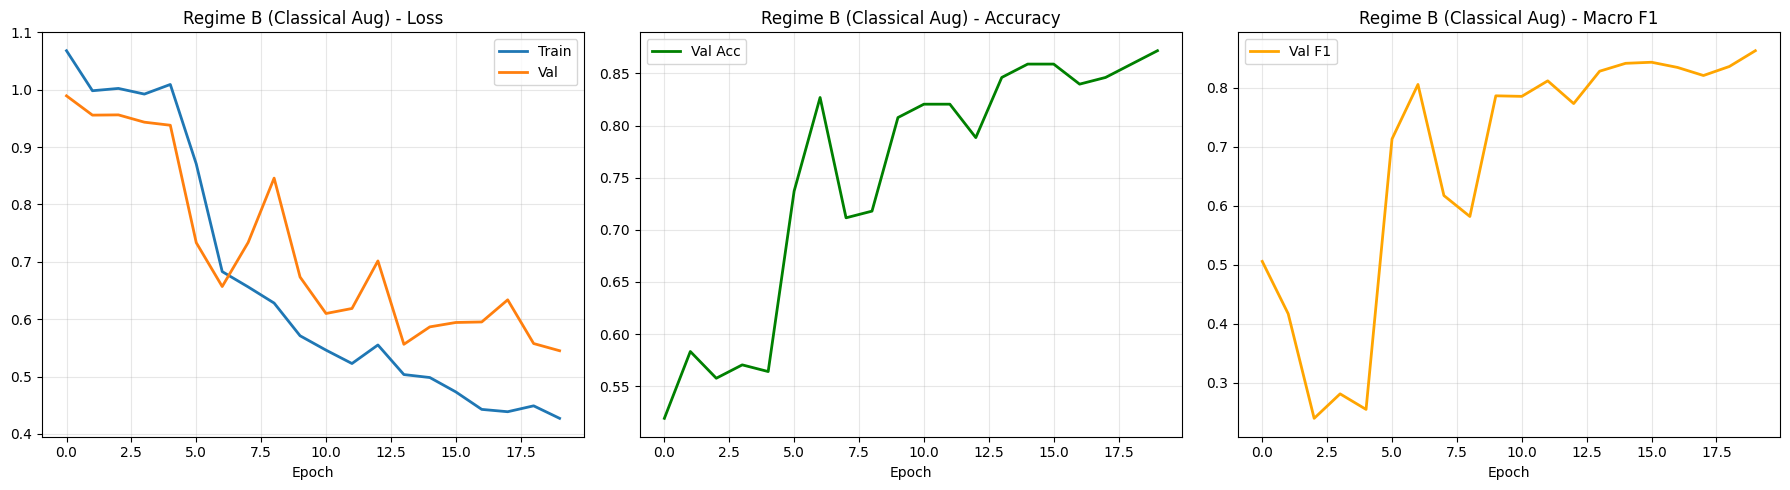


--- Regime B (Classical Aug) ---
              precision    recall  f1-score   support

      normal       0.75      0.89      0.81        27
      benign       0.88      0.91      0.89        87
   malignant       0.97      0.79      0.87        42

    accuracy                           0.87       156
   macro avg       0.87      0.86      0.86       156
weighted avg       0.88      0.87      0.87       156



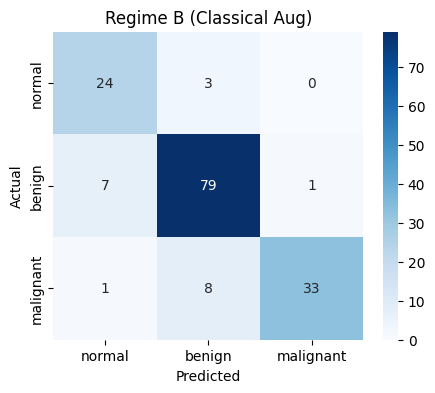

In [20]:
# CELL 4: Regime B - Classical Augmentation
print("="*60)
print("REGIME B: Classical Augmentation")
print("="*60)

train_loader_aug = DataLoader(BUSIDataset(train_paths, train_labels, classical_transform),
                              batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

model_b = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_b.fc = nn.Linear(model_b.fc.in_features, len(classes))
model_b = model_b.to(device)

optimizer_b = optim.Adam(model_b.parameters(), lr=1e-4, weight_decay=1e-4)

best_model_b, history_b = train_model(model_b, criterion, optimizer_b, train_loader_aug, val_loader)
plot_training_history(history_b, "Regime B (Classical Aug)")
metrics_b = evaluate_on_test(best_model_b, test_loader, classes, "Regime B (Classical Aug)")
final_metrics['B: Classical Aug'] = metrics_b

In [21]:
# CELL 5: WGAN-GP Architecture (Deeper Generator + Critic)
# Key improvements over original cGAN:
#   - Deeper generator with ConvTranspose2d progressive upsampling (8->128)
#   - Critic with InstanceNorm (compatible with gradient penalty)
#   - No Sigmoid in critic output (Wasserstein loss)

LATENT_DIM = 100
IMAGE_SIZE = 128
CHANNELS = 3
NUM_CLASSES = len(classes)
EMBED_DIM = 50

class Generator(nn.Module):
    """Deeper generator: FC -> reshape(512,8,8) -> 4x ConvTranspose2d -> (3,128,128)"""
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, EMBED_DIM)
        self.project = nn.Sequential(
            nn.Linear(LATENT_DIM + EMBED_DIM, 512 * 8 * 8),
            nn.BatchNorm1d(512 * 8 * 8),
            nn.ReLU(True)
        )
        self.main = nn.Sequential(
            # 8x8 -> 16x16
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            # 16x16 -> 32x32
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            # 32x32 -> 64x64
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),
            # 64x64 -> 128x128
            nn.ConvTranspose2d(64, CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        c = self.label_emb(labels)
        x = torch.cat([noise, c], dim=-1)
        x = self.project(x)
        x = x.view(-1, 512, 8, 8)
        return self.main(x)


class Critic(nn.Module):
    """WGAN-GP critic: Conv blocks with InstanceNorm (no BatchNorm), no Sigmoid output."""
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, EMBED_DIM)
        self.features = nn.Sequential(
            # 128x128 -> 64x64
            nn.Conv2d(CHANNELS, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, True),
            # 64x64 -> 32x32
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(128, affine=True), nn.LeakyReLU(0.2, True),
            # 32x32 -> 16x16
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(256, affine=True), nn.LeakyReLU(0.2, True),
            # 16x16 -> 8x8
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(512, affine=True), nn.LeakyReLU(0.2, True),
        )
        self.output = nn.Linear(512 * 8 * 8 + EMBED_DIM, 1)  # No sigmoid

    def forward(self, img, labels):
        feat = self.features(img)
        feat = feat.view(feat.size(0), -1)
        c = self.label_emb(labels)
        return self.output(torch.cat([feat, c], dim=-1))


def compute_gradient_penalty(critic, real_imgs, fake_imgs, labels):
    """WGAN-GP gradient penalty on interpolated samples."""
    batch_size = real_imgs.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    interp = (alpha * real_imgs.data + (1 - alpha) * fake_imgs.data).requires_grad_(True)
    d_interp = critic(interp, labels)
    grads = torch.autograd.grad(
        outputs=d_interp, inputs=interp,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True, retain_graph=True
    )[0]
    grads = grads.view(batch_size, -1)
    return ((grads.norm(2, dim=1) - 1) ** 2).mean()


generator = Generator().to(device)
critic = Critic().to(device)

print(f"Generator params: {sum(p.numel() for p in generator.parameters()):,}")
print(f"Critic params:    {sum(p.numel() for p in critic.parameters()):,}")
print("WGAN-GP architecture initialized.")

Generator params: 7,770,134
Critic params:    2,790,345
WGAN-GP architecture initialized.


--- WGAN-GP Training: 200 epochs, N_CRITIC=5 ---
  Epoch [20/200] | C: -46.2157 | G: 58.5155 | W-Dist: 62.9232
  Epoch [40/200] | C: -42.6926 | G: 52.6997 | W-Dist: 59.0910


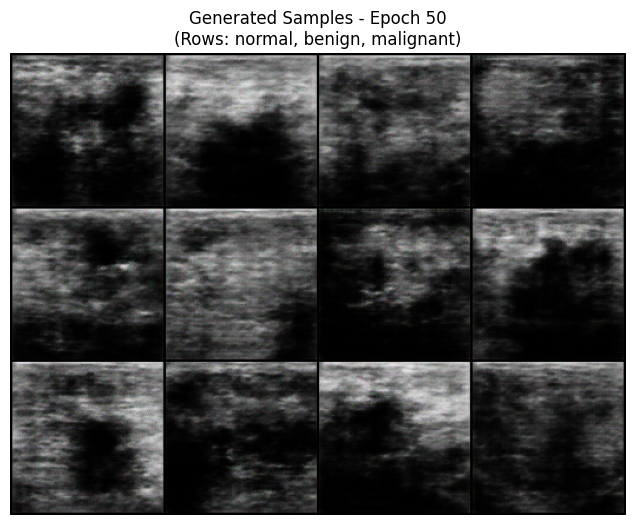

  Epoch [60/200] | C: -47.8478 | G: 60.2646 | W-Dist: 66.2238
  Epoch [80/200] | C: -55.0693 | G: 84.7851 | W-Dist: 75.5377
  Epoch [100/200] | C: -58.9023 | G: 100.6918 | W-Dist: 80.9520


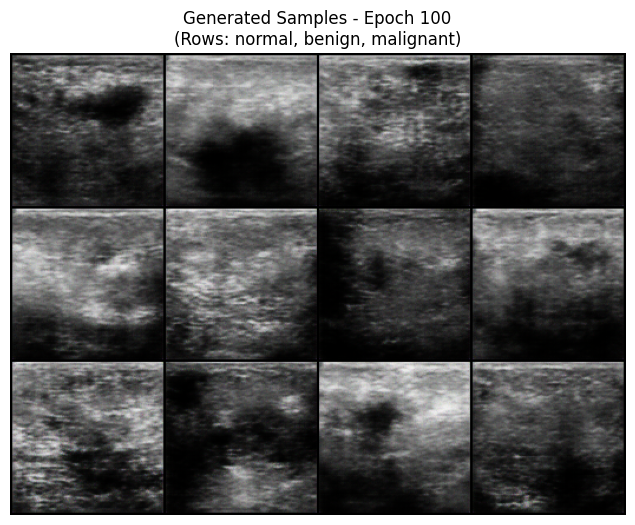

  Epoch [120/200] | C: -62.3391 | G: 119.6093 | W-Dist: 87.8875
  Epoch [140/200] | C: -65.3514 | G: 127.7685 | W-Dist: 94.0381


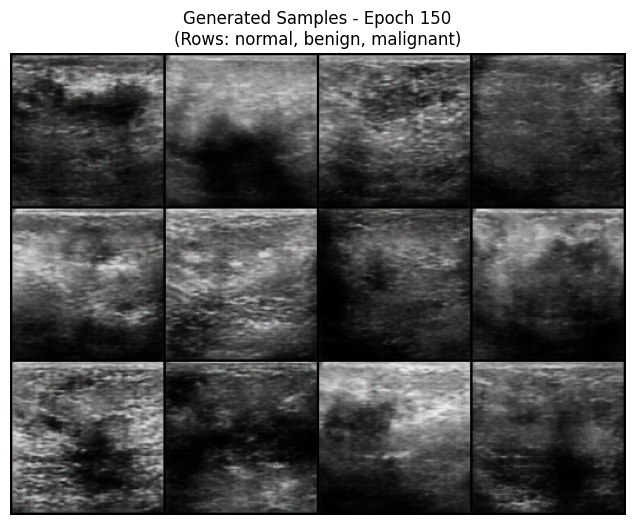

  Epoch [160/200] | C: -67.8100 | G: 145.8270 | W-Dist: 96.7056
  Epoch [180/200] | C: -73.0355 | G: 145.9376 | W-Dist: 101.4169
  Epoch [200/200] | C: -72.9552 | G: 155.4661 | W-Dist: 103.4984


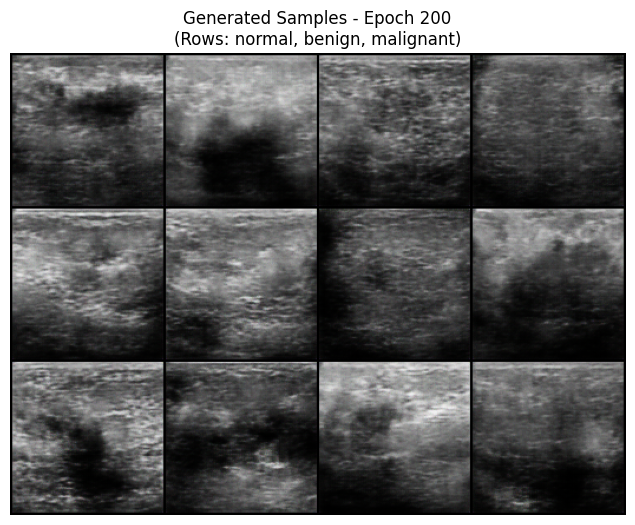


GAN training complete in 56m 22s


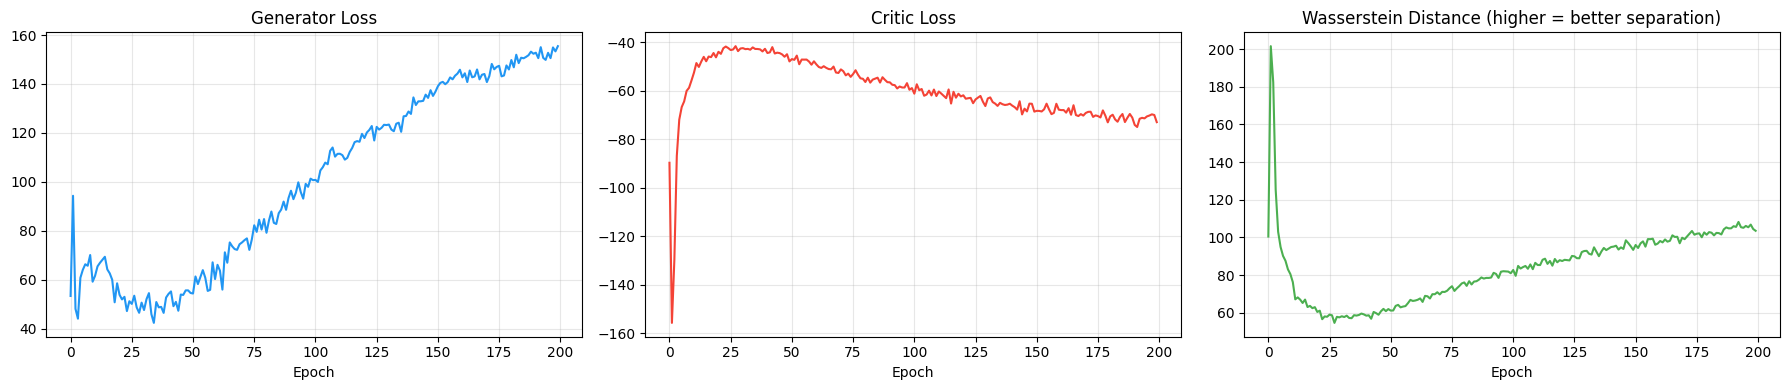

In [22]:
# CELL 6: WGAN-GP Training (200 epochs)
# Key differences from standard cGAN:
#   - Critic trained 5x per generator step
#   - Gradient penalty (lambda=10) instead of BCE
#   - Wasserstein distance tracked as quality metric
#   - Periodic sample visualization with fixed noise

gan_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # [-1, 1]
])

gan_dataset = BUSIDataset(train_paths, train_labels, gan_transform)
gan_loader = DataLoader(gan_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)

NUM_GAN_EPOCHS = 200
N_CRITIC = 5
LAMBDA_GP = 10

optimizer_G = optim.Adam(generator.parameters(), lr=1e-4, betas=(0.0, 0.9))
optimizer_C = optim.Adam(critic.parameters(), lr=1e-4, betas=(0.0, 0.9))

# Fixed noise for consistent visualization across epochs
fixed_z = torch.randn(NUM_CLASSES * 4, LATENT_DIM).to(device)
fixed_labels = torch.arange(0, NUM_CLASSES).repeat(4).to(device)

g_losses, c_losses, w_distances = [], [], []

print(f"--- WGAN-GP Training: {NUM_GAN_EPOCHS} epochs, N_CRITIC={N_CRITIC} ---")
gan_start = time.time()

for epoch in range(NUM_GAN_EPOCHS):
    g_loss_sum, c_loss_sum, w_dist_sum = 0.0, 0.0, 0.0
    n_batches = 0

    for real_imgs, real_lbls in gan_loader:
        bs = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        real_lbls = real_lbls.to(device)

        # ---- Train Critic (N_CRITIC steps) ----
        for _ in range(N_CRITIC):
            z = torch.randn(bs, LATENT_DIM, device=device)
            fake_imgs = generator(z, real_lbls).detach()

            c_real = critic(real_imgs, real_lbls)
            c_fake = critic(fake_imgs, real_lbls)
            gp = compute_gradient_penalty(critic, real_imgs, fake_imgs, real_lbls)

            loss_c = c_fake.mean() - c_real.mean() + LAMBDA_GP * gp
            optimizer_C.zero_grad()
            loss_c.backward()
            optimizer_C.step()

        # ---- Train Generator ----
        z = torch.randn(bs, LATENT_DIM, device=device)
        gen_lbls = torch.randint(0, NUM_CLASSES, (bs,), device=device)
        fake_imgs = generator(z, gen_lbls)
        loss_g = -critic(fake_imgs, gen_lbls).mean()

        optimizer_G.zero_grad()
        loss_g.backward()
        optimizer_G.step()

        g_loss_sum += loss_g.item()
        c_loss_sum += loss_c.item()
        w_dist_sum += (c_real.mean() - c_fake.mean()).item()
        n_batches += 1

    g_losses.append(g_loss_sum / n_batches)
    c_losses.append(c_loss_sum / n_batches)
    w_distances.append(w_dist_sum / n_batches)

    if (epoch + 1) % 20 == 0:
        print(f"  Epoch [{epoch+1}/{NUM_GAN_EPOCHS}] | C: {c_losses[-1]:.4f} | G: {g_losses[-1]:.4f} | W-Dist: {w_distances[-1]:.4f}")

    # Visualize with fixed noise every 50 epochs
    if (epoch + 1) % 50 == 0:
        generator.eval()
        with torch.no_grad():
            samples = generator(fixed_z, fixed_labels)
            samples = (samples * 0.5 + 0.5).clamp(0, 1)
            grid = make_grid(samples, nrow=4)
            plt.figure(figsize=(8, 6))
            plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
            plt.title(f'Generated Samples - Epoch {epoch+1}\n(Rows: normal, benign, malignant)')
            plt.axis('off')
            plt.show()
        generator.train()

gan_time = time.time() - gan_start
print(f"\nGAN training complete in {gan_time//60:.0f}m {gan_time%60:.0f}s")

# ---- Plot GAN Training Curves ----
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(g_losses, color='#2196F3', lw=1.5)
axes[0].set_title('Generator Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True, alpha=0.3)
axes[1].plot(c_losses, color='#F44336', lw=1.5)
axes[1].set_title('Critic Loss'); axes[1].set_xlabel('Epoch'); axes[1].grid(True, alpha=0.3)
axes[2].plot(w_distances, color='#4CAF50', lw=1.5)
axes[2].set_title('Wasserstein Distance (higher = better separation)'); axes[2].set_xlabel('Epoch'); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

--- Final Generated Sample Grid ---


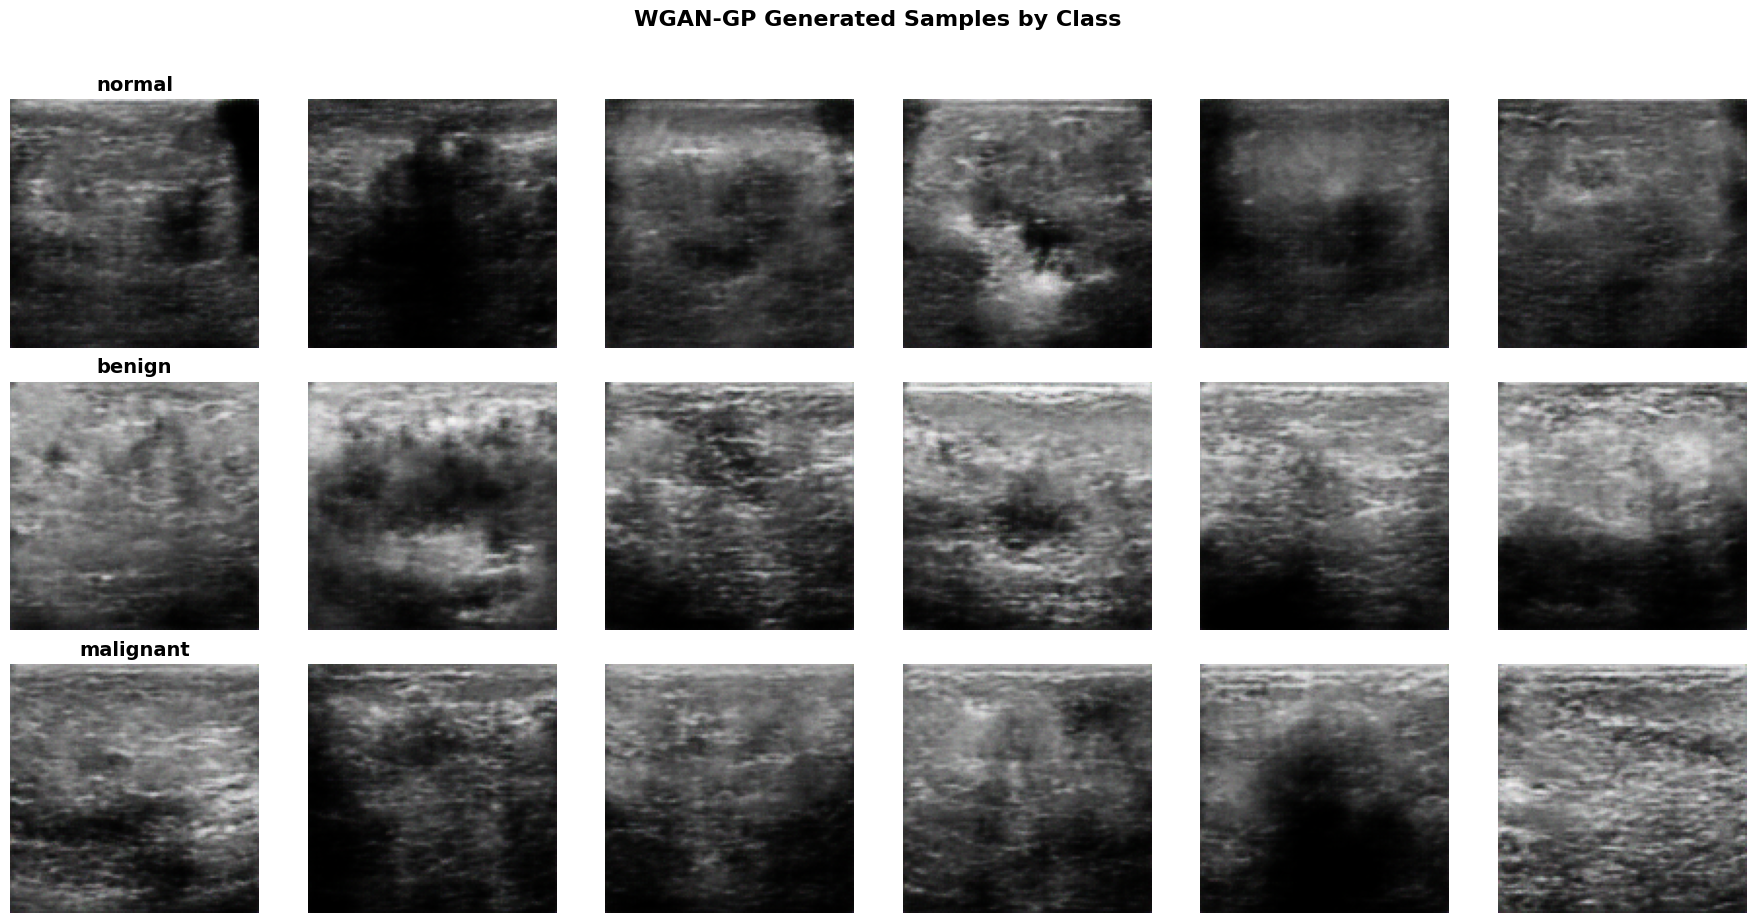


--- Computing FID Scores (lower = better) ---
FID computation skipped: FrechetInceptionDistance metric requires that `Torch-fidelity` is installed. Either install as `pip install torchmetrics[image]` or `pip install torch-fidelity`.
Continuing without FID scores.


In [23]:
# CELL 7: GAN Quality Evaluation — FID Scores + Sample Grid

# ---- Final Sample Visualization ----
print("--- Final Generated Sample Grid ---")
generator.eval()
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
with torch.no_grad():
    for ci, cn in enumerate(classes):
        for col in range(6):
            z = torch.randn(1, LATENT_DIM, device=device)
            lbl = torch.tensor([ci], device=device)
            sample = generator(z, lbl)
            sample = (sample * 0.5 + 0.5).clamp(0, 1)
            axes[ci, col].imshow(sample.squeeze().permute(1, 2, 0).cpu().numpy())
            axes[ci, col].axis('off')
            if col == 0:
                axes[ci, col].set_title(cn, fontsize=14, fontweight='bold')
plt.suptitle('WGAN-GP Generated Samples by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ---- FID Score Computation ----
try:
    from torchmetrics.image.fid import FrechetInceptionDistance

    print("\n--- Computing FID Scores (lower = better) ---")
    fid_scores = {}

    raw_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor()
    ])

    for ci, cn in enumerate(classes):
        fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)

        # Add real images
        real_count = 0
        for path, label in zip(train_paths, train_labels):
            if label == ci:
                img = Image.open(path).convert('RGB')
                img_t = raw_transform(img).unsqueeze(0).to(device)
                fid.update(img_t, real=True)
                real_count += 1

        # Generate same number of fake images
        with torch.no_grad():
            for _ in range(real_count):
                z = torch.randn(1, LATENT_DIM, device=device)
                lbl = torch.tensor([ci], device=device)
                fake = generator(z, lbl)
                fake = (fake * 0.5 + 0.5).clamp(0, 1)
                fid.update(fake, real=False)

        score = fid.compute().item()
        fid_scores[cn] = score
        print(f"  FID ({cn}): {score:.2f}")

    avg_fid = np.mean(list(fid_scores.values()))
    print(f"  Average FID: {avg_fid:.2f}")

    # Plot FID
    plt.figure(figsize=(8, 4))
    bars = plt.bar(fid_scores.keys(), fid_scores.values(), color=['#4CAF50', '#9C27B0', '#F44336'], edgecolor='black')
    plt.title('FID Scores per Class (Lower = Better)', fontsize=14, fontweight='bold')
    plt.ylabel('FID Score'); plt.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, fid_scores.values()):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', ha='center', fontweight='bold')
    plt.tight_layout(); plt.show()

except Exception as e:
    print(f"FID computation skipped: {e}")
    print("Continuing without FID scores.")

REGIME C: Vanilla WGAN-GP Augmentation
Target per class: 262
Synthetic needed — Normal: 182, Benign: 0, Malignant: 136
Regime C dataset: 786 images (real + synthetic, classical aug on real)
  [Freeze] Backbone frozen for first 5 epochs
Epoch [1/20] | Train Loss: 1.0915 | Val Loss: 1.1363 Acc: 0.3333 F1: 0.2981
Epoch [2/20] | Train Loss: 1.0128 | Val Loss: 1.1798 Acc: 0.2949 F1: 0.2710
Epoch [3/20] | Train Loss: 0.9855 | Val Loss: 1.1371 Acc: 0.3141 F1: 0.2845
Epoch [4/20] | Train Loss: 0.9646 | Val Loss: 1.0704 Acc: 0.4487 F1: 0.3975
Epoch [5/20] | Train Loss: 0.9381 | Val Loss: 1.0435 Acc: 0.4808 F1: 0.4087
  [Unfreeze] All layers trainable from epoch 6
Epoch [6/20] | Train Loss: 0.7365 | Val Loss: 0.8528 Acc: 0.6026 F1: 0.4235
Epoch [7/20] | Train Loss: 0.5874 | Val Loss: 0.7671 Acc: 0.7179 F1: 0.6896
Epoch [8/20] | Train Loss: 0.5393 | Val Loss: 0.7007 Acc: 0.7692 F1: 0.7162
Epoch [9/20] | Train Loss: 0.5156 | Val Loss: 0.7075 Acc: 0.7885 F1: 0.7363
Epoch [10/20] | Train Loss: 0.490

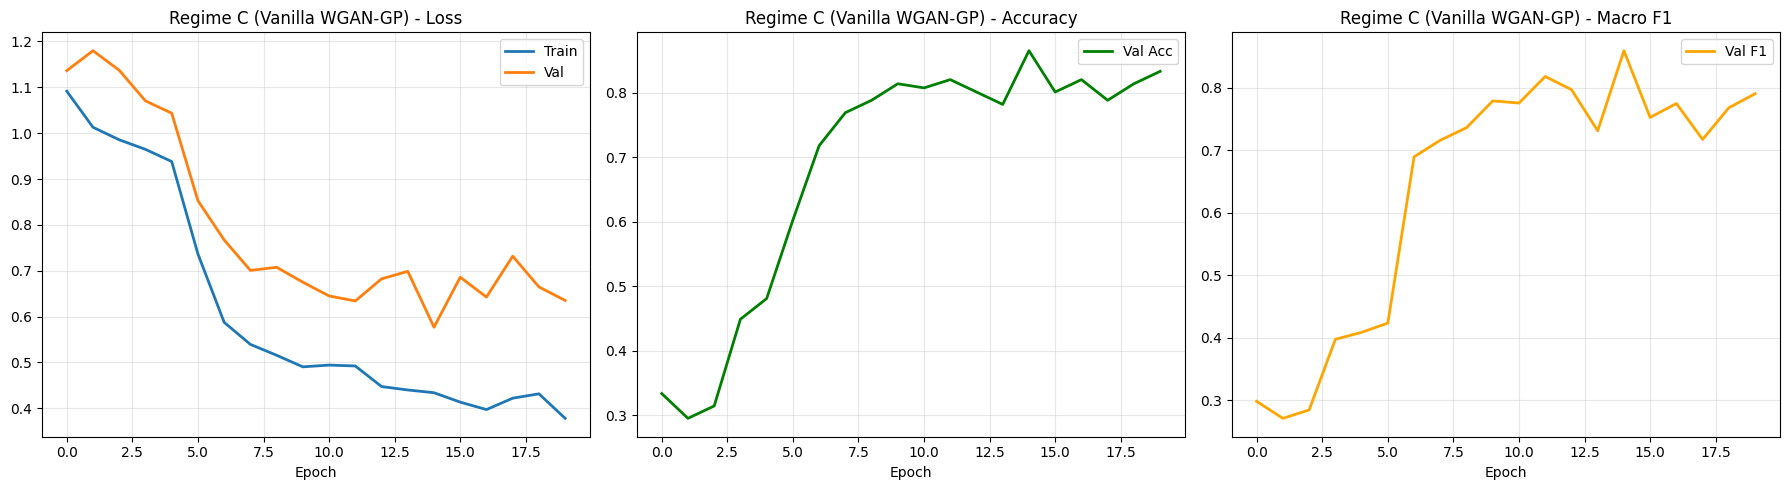


--- Regime C (Vanilla WGAN-GP) ---
              precision    recall  f1-score   support

      normal       0.76      0.81      0.79        27
      benign       0.91      0.86      0.89        87
   malignant       0.78      0.83      0.80        42

    accuracy                           0.85       156
   macro avg       0.82      0.84      0.83       156
weighted avg       0.85      0.85      0.85       156



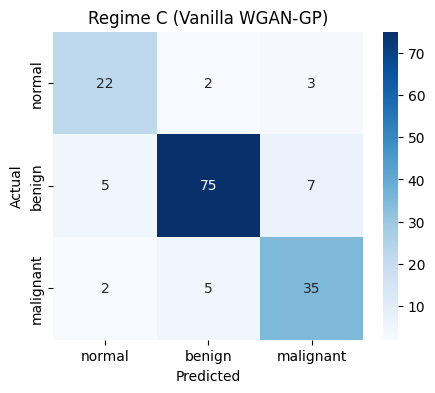

In [24]:
# CELL 8: Regime C - Vanilla WGAN-GP Augmentation
# Real training data uses classical_transform (fair comparison with Regime B)
print("="*60)
print("REGIME C: Vanilla WGAN-GP Augmentation")
print("="*60)

normal_count = train_labels.count(0)
benign_count = train_labels.count(1)
malignant_count = train_labels.count(2)
target_count = max(normal_count, benign_count, malignant_count)

synth_normal_needed = max(0, target_count - normal_count)
synth_malignant_needed = max(0, target_count - malignant_count)
synth_benign_needed = max(0, target_count - benign_count)

print(f"Target per class: {target_count}")
print(f"Synthetic needed — Normal: {synth_normal_needed}, Benign: {synth_benign_needed}, Malignant: {synth_malignant_needed}")

generator.eval()
c_synth_imgs, c_synth_labels = [], []

with torch.no_grad():
    for class_idx, needed in [(0, synth_normal_needed), (1, synth_benign_needed), (2, synth_malignant_needed)]:
        for _ in range(needed):
            z = torch.randn(1, LATENT_DIM, device=device)
            lbl = torch.tensor([class_idx], device=device)
            sample = generator(z, lbl)
            sample = F.interpolate(sample, size=(224, 224), mode='bilinear', align_corners=False)
            sample = (sample * 0.5 + 0.5).clamp(0, 1)
            norm_img = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(sample.squeeze(0))
            c_synth_imgs.append(norm_img)
            c_synth_labels.append(class_idx)

if c_synth_imgs:
    c_synth_ds = TensorDataset(torch.stack(c_synth_imgs).cpu(),
                                torch.tensor(c_synth_labels, dtype=torch.long))
    real_ds_c = BUSIDataset(train_paths, train_labels, classical_transform)
    regime_c_ds = ConcatDataset([real_ds_c, c_synth_ds])
else:
    regime_c_ds = BUSIDataset(train_paths, train_labels, classical_transform)

c_loader = DataLoader(regime_c_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
print(f"Regime C dataset: {len(regime_c_ds)} images (real + synthetic, classical aug on real)")

model_c = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_c.fc = nn.Linear(model_c.fc.in_features, len(classes))
model_c = model_c.to(device)
optimizer_c = optim.Adam(model_c.parameters(), lr=1e-4, weight_decay=1e-4)

best_model_c, history_c = train_model(model_c, criterion, optimizer_c, c_loader, val_loader)
plot_training_history(history_c, "Regime C (Vanilla WGAN-GP)")
metrics_c = evaluate_on_test(best_model_c, test_loader, classes, "Regime C (Vanilla WGAN-GP)")
final_metrics['C: Vanilla WGAN-GP'] = metrics_c

REGIME D: Mask-Aware WGAN-GP Augmentation
  benign masks found: 437
  malignant masks found: 210
  Normal background images: 80
  Generated 136 mask-aware malignant images

  Visualizing mask-aware blending process...


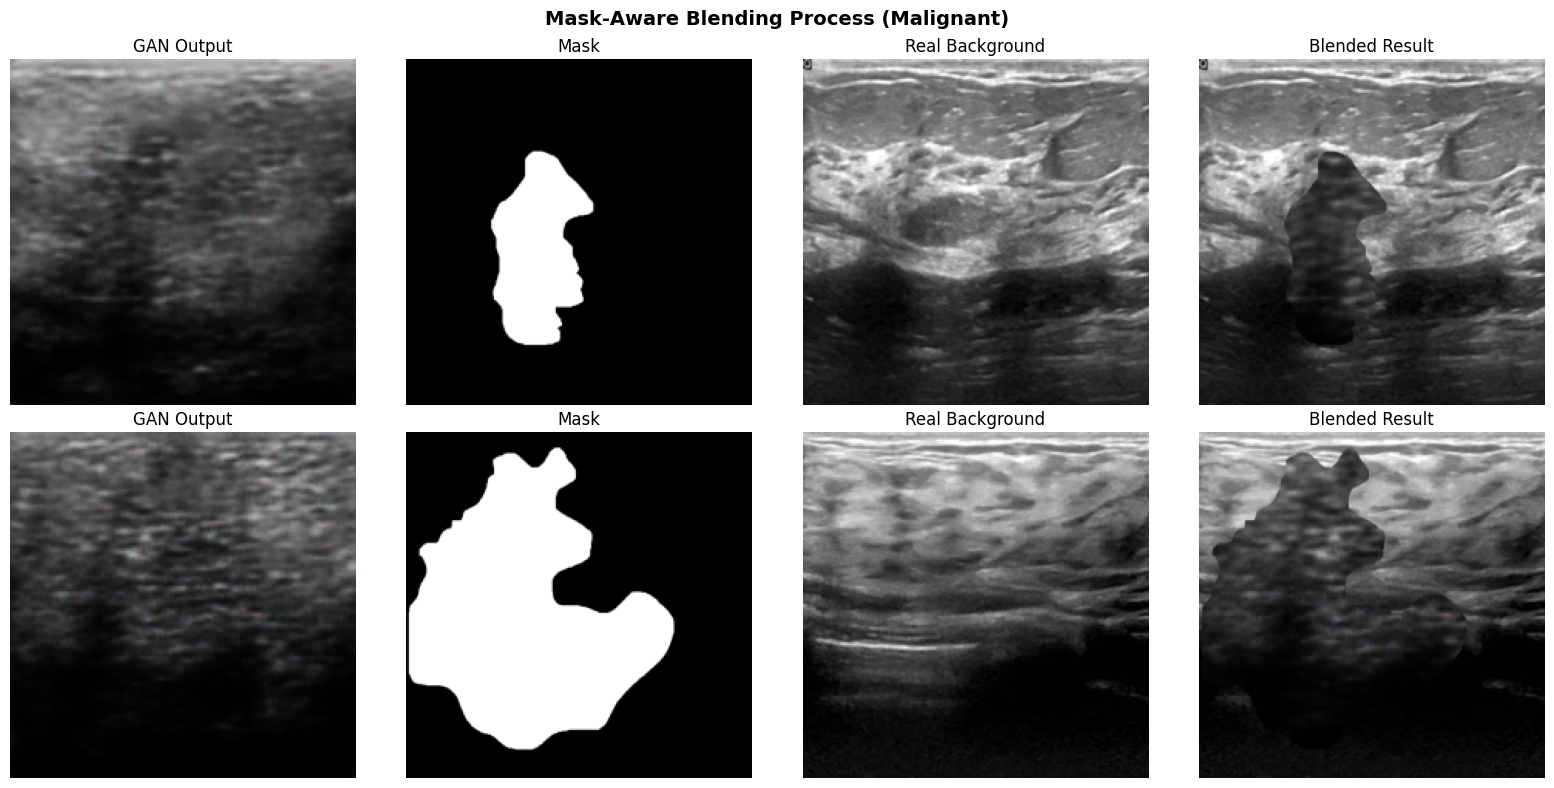


Regime D dataset: 786 images (real + mask-aware synthetic)
  [Freeze] Backbone frozen for first 5 epochs
Epoch [1/20] | Train Loss: 1.0797 | Val Loss: 1.0305 Acc: 0.4808 F1: 0.4301
Epoch [2/20] | Train Loss: 1.0057 | Val Loss: 1.0933 Acc: 0.4167 F1: 0.3821
Epoch [3/20] | Train Loss: 0.9515 | Val Loss: 1.0456 Acc: 0.4679 F1: 0.4271
Epoch [4/20] | Train Loss: 0.9069 | Val Loss: 1.0949 Acc: 0.3974 F1: 0.3508
Epoch [5/20] | Train Loss: 0.8887 | Val Loss: 1.1525 Acc: 0.3013 F1: 0.2422
  [Unfreeze] All layers trainable from epoch 6
Epoch [6/20] | Train Loss: 0.6982 | Val Loss: 0.8795 Acc: 0.6474 F1: 0.4803
Epoch [7/20] | Train Loss: 0.6081 | Val Loss: 0.8947 Acc: 0.6282 F1: 0.5114
Epoch [8/20] | Train Loss: 0.5444 | Val Loss: 1.1365 Acc: 0.5641 F1: 0.4541
Epoch [9/20] | Train Loss: 0.5103 | Val Loss: 0.9212 Acc: 0.6667 F1: 0.5174
Epoch [10/20] | Train Loss: 0.4964 | Val Loss: 0.7650 Acc: 0.7308 F1: 0.6435
Epoch [11/20] | Train Loss: 0.4780 | Val Loss: 0.7249 Acc: 0.8013 F1: 0.7485
Epoch [12

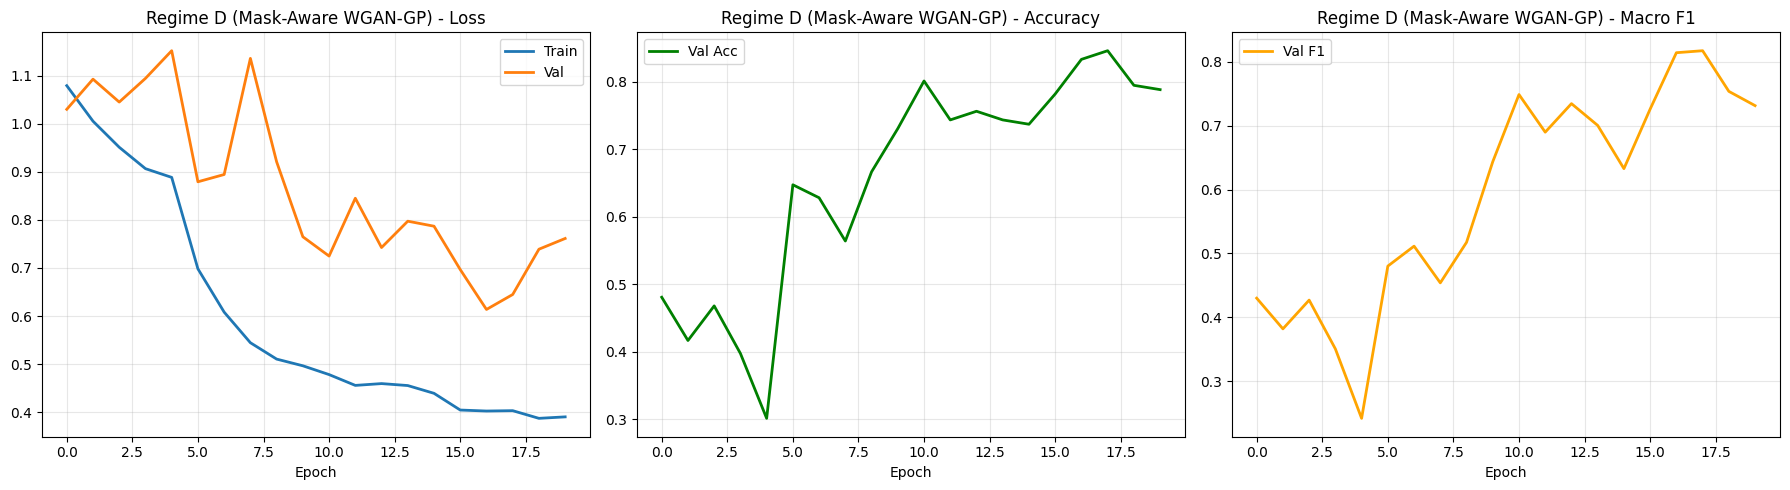


--- Regime D (Mask-Aware WGAN-GP) ---
              precision    recall  f1-score   support

      normal       0.93      0.48      0.63        27
      benign       0.90      0.87      0.89        87
   malignant       0.67      0.93      0.78        42

    accuracy                           0.82       156
   macro avg       0.84      0.76      0.77       156
weighted avg       0.85      0.82      0.82       156



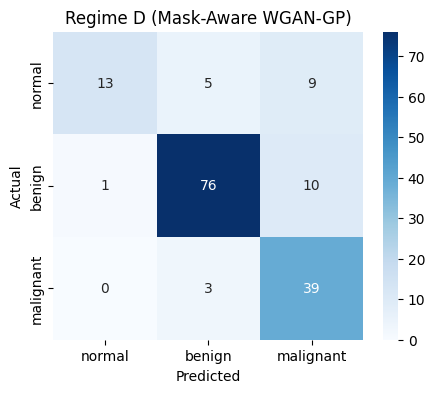

In [25]:
# CELL 9: Regime D - Mask-Aware WGAN-GP Augmentation
# Key improvements:
#   - Real tissue backgrounds from normal class (not random noise)
#   - Masks for BOTH benign and malignant classes
#   - Classical augmentation on real training data
print("="*60)
print("REGIME D: Mask-Aware WGAN-GP Augmentation")
print("="*60)

# ---- Collect masks for both classes ----
class_masks = {}
for cname in ['benign', 'malignant']:
    cpath = os.path.join(DATA_PATH, cname)
    masks = glob.glob(os.path.join(cpath, '*_mask.png')) if os.path.exists(cpath) else []
    class_masks[cname] = masks
    print(f"  {cname} masks found: {len(masks)}")

# Normal images for real tissue backgrounds
normal_bg_paths = [p for p, l in zip(train_paths, train_labels) if l == 0]
print(f"  Normal background images: {len(normal_bg_paths)}")

# ---- Helper: load mask & background ----
def load_mask_tensor(mask_path, size=224):
    mask = Image.open(mask_path).convert('L').resize((size, size))
    return torch.from_numpy(np.array(mask) / 255.0).float().unsqueeze(0)

def load_real_background(size=224):
    """Load a random normal ultrasound image as realistic tissue background."""
    bg = Image.open(random.choice(normal_bg_paths)).convert('RGB')
    bg_tensor = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor()  # [0, 1]
    ])(bg)
    return bg_tensor

# ---- Generate mask-aware synthetic images ----
generator.eval()
d_synth_imgs, d_synth_labels = [], []

with torch.no_grad():
    # Normal class: pure GAN output (no lesion masks)
    for _ in range(synth_normal_needed):
        z = torch.randn(1, LATENT_DIM, device=device)
        sample = generator(z, torch.tensor([0], device=device))
        sample = F.interpolate(sample, size=(224, 224), mode='bilinear', align_corners=False)
        sample = (sample * 0.5 + 0.5).clamp(0, 1)
        norm_img = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(sample.squeeze(0))
        d_synth_imgs.append(norm_img)
        d_synth_labels.append(0)

    # Benign class: mask-aware blending with benign masks + real backgrounds
    if synth_benign_needed > 0 and class_masks['benign']:
        sel_masks = random.choices(class_masks['benign'], k=synth_benign_needed)
        for i in range(synth_benign_needed):
            z = torch.randn(1, LATENT_DIM, device=device)
            sample = generator(z, torch.tensor([1], device=device))
            sample = F.interpolate(sample, size=(224, 224), mode='bilinear', align_corners=False)
            sample = (sample * 0.5 + 0.5).clamp(0, 1).squeeze(0).cpu()

            mask = load_mask_tensor(sel_masks[i])
            bg = load_real_background()
            combined = (sample * mask + bg * (1 - mask)).clamp(0, 1)

            norm_img = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(combined)
            d_synth_imgs.append(norm_img.to(device))
            d_synth_labels.append(1)
        print(f"  Generated {synth_benign_needed} mask-aware benign images")

    # Malignant class: mask-aware blending with malignant masks + real backgrounds
    if synth_malignant_needed > 0 and class_masks['malignant']:
        sel_masks = random.choices(class_masks['malignant'], k=synth_malignant_needed)
        for i in range(synth_malignant_needed):
            z = torch.randn(1, LATENT_DIM, device=device)
            sample = generator(z, torch.tensor([2], device=device))
            sample = F.interpolate(sample, size=(224, 224), mode='bilinear', align_corners=False)
            sample = (sample * 0.5 + 0.5).clamp(0, 1).squeeze(0).cpu()

            mask = load_mask_tensor(sel_masks[i])
            bg = load_real_background()
            combined = (sample * mask + bg * (1 - mask)).clamp(0, 1)

            norm_img = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(combined)
            d_synth_imgs.append(norm_img.to(device))
            d_synth_labels.append(2)
        print(f"  Generated {synth_malignant_needed} mask-aware malignant images")

# ---- Visualize mask-aware blending examples ----
if class_masks['malignant'] and synth_malignant_needed > 0:
    print("\n  Visualizing mask-aware blending process...")
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    with torch.no_grad():
        for row in range(2):
            z = torch.randn(1, LATENT_DIM, device=device)
            sample = generator(z, torch.tensor([2], device=device))
            sample = F.interpolate(sample, size=(224, 224), mode='bilinear', align_corners=False)
            sample = (sample * 0.5 + 0.5).clamp(0, 1).squeeze(0).cpu()
            mask = load_mask_tensor(random.choice(class_masks['malignant']))
            bg = load_real_background()
            combined = (sample * mask + bg * (1 - mask)).clamp(0, 1)

            axes[row, 0].imshow(sample.permute(1, 2, 0).numpy()); axes[row, 0].set_title('GAN Output')
            axes[row, 1].imshow(mask.squeeze(), cmap='gray'); axes[row, 1].set_title('Mask')
            axes[row, 2].imshow(bg.permute(1, 2, 0).numpy()); axes[row, 2].set_title('Real Background')
            axes[row, 3].imshow(combined.permute(1, 2, 0).numpy()); axes[row, 3].set_title('Blended Result')
            for ax in axes[row]: ax.axis('off')
    plt.suptitle('Mask-Aware Blending Process (Malignant)', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

# ---- Build combined dataset ----
if d_synth_imgs:
    d_synth_ds = TensorDataset(torch.stack([t.cpu() for t in d_synth_imgs]),
                                torch.tensor(d_synth_labels, dtype=torch.long))
    real_ds_d = BUSIDataset(train_paths, train_labels, classical_transform)
    regime_d_ds = ConcatDataset([real_ds_d, d_synth_ds])
else:
    regime_d_ds = BUSIDataset(train_paths, train_labels, classical_transform)

d_loader = DataLoader(regime_d_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
print(f"\nRegime D dataset: {len(regime_d_ds)} images (real + mask-aware synthetic)")

# ---- Train classifier ----
model_d = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_d.fc = nn.Linear(model_d.fc.in_features, len(classes))
model_d = model_d.to(device)
optimizer_d = optim.Adam(model_d.parameters(), lr=1e-4, weight_decay=1e-4)

best_model_d, history_d = train_model(model_d, criterion, optimizer_d, d_loader, val_loader)
plot_training_history(history_d, "Regime D (Mask-Aware WGAN-GP)")
metrics_d = evaluate_on_test(best_model_d, test_loader, classes, "Regime D (Mask-Aware WGAN-GP)")
final_metrics['D: Mask-Aware WGAN-GP'] = metrics_d


ABLATION STUDY - FINAL COMPARATIVE ANALYSIS

FINAL COMPARATIVE RESULTS
                       Accuracy  Macro F1  Normal F1  Benign F1  Malignant F1
A: Baseline              0.8141    0.7801     0.6800     0.8556        0.8049
B: Classical Aug         0.8718    0.8582     0.8136     0.8927        0.8684
C: Vanilla WGAN-GP       0.8462    0.8260     0.7857     0.8876        0.8046
D: Mask-Aware WGAN-GP    0.8205    0.7677     0.6341     0.8889        0.7800


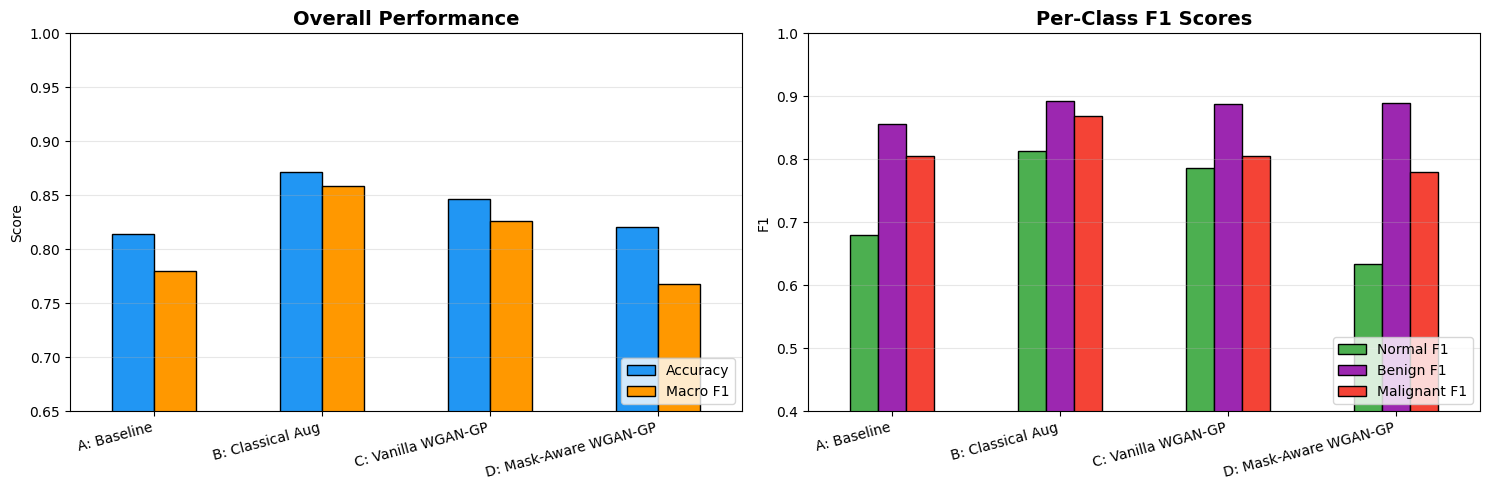

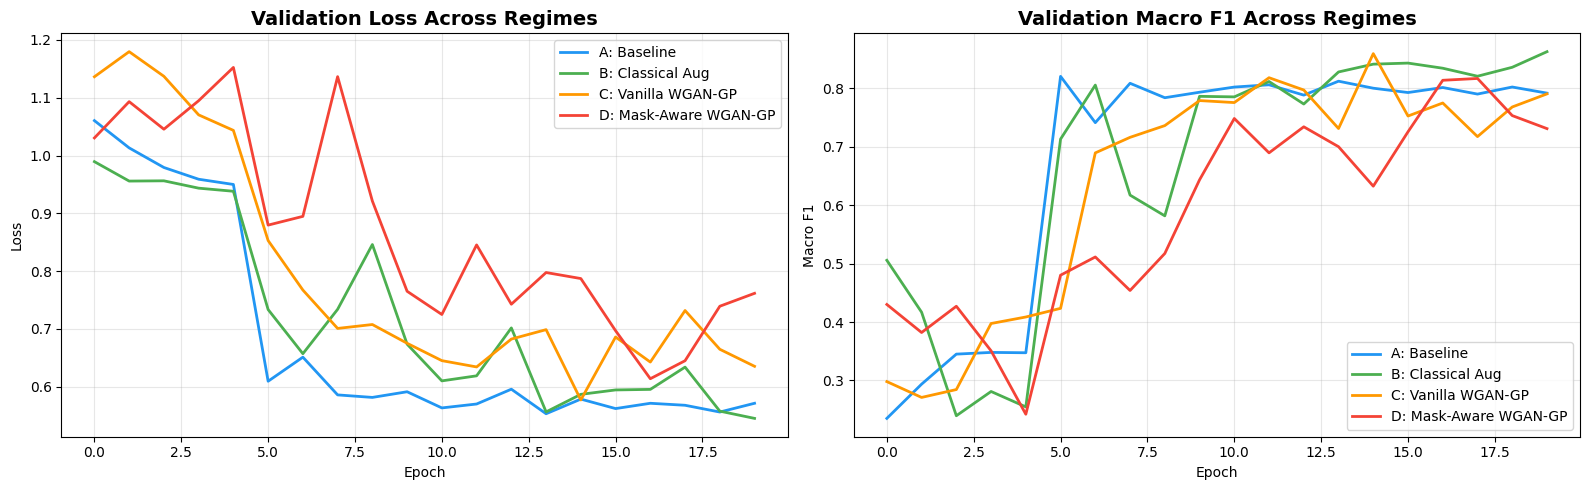


Ablation study complete!


In [26]:
# CELL 10: Final Comparative Analysis
print("\n" + "="*70)
print("ABLATION STUDY - FINAL COMPARATIVE ANALYSIS")
print("="*70)

# Summary table + bar charts
plot_final_comparison(final_metrics)

# Overlaid training curves across all regimes
all_histories = {
    'A: Baseline': history_a,
    'B: Classical Aug': history_b,
    'C: Vanilla WGAN-GP': history_c,
    'D: Mask-Aware WGAN-GP': history_d,
}
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for idx, (name, hist) in enumerate(all_histories.items()):
    axes[0].plot(hist['val_loss'], label=name, lw=2, color=colors[idx])
    axes[1].plot(hist['val_f1'], label=name, lw=2, color=colors[idx])

axes[0].set_title('Validation Loss Across Regimes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Macro F1 Across Regimes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print("\nAblation study complete!")